In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [29]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [30]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [31]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

**Step 5: Duplicate checking**

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
X = df.drop("Price",axis=1)

y = df["Price"]

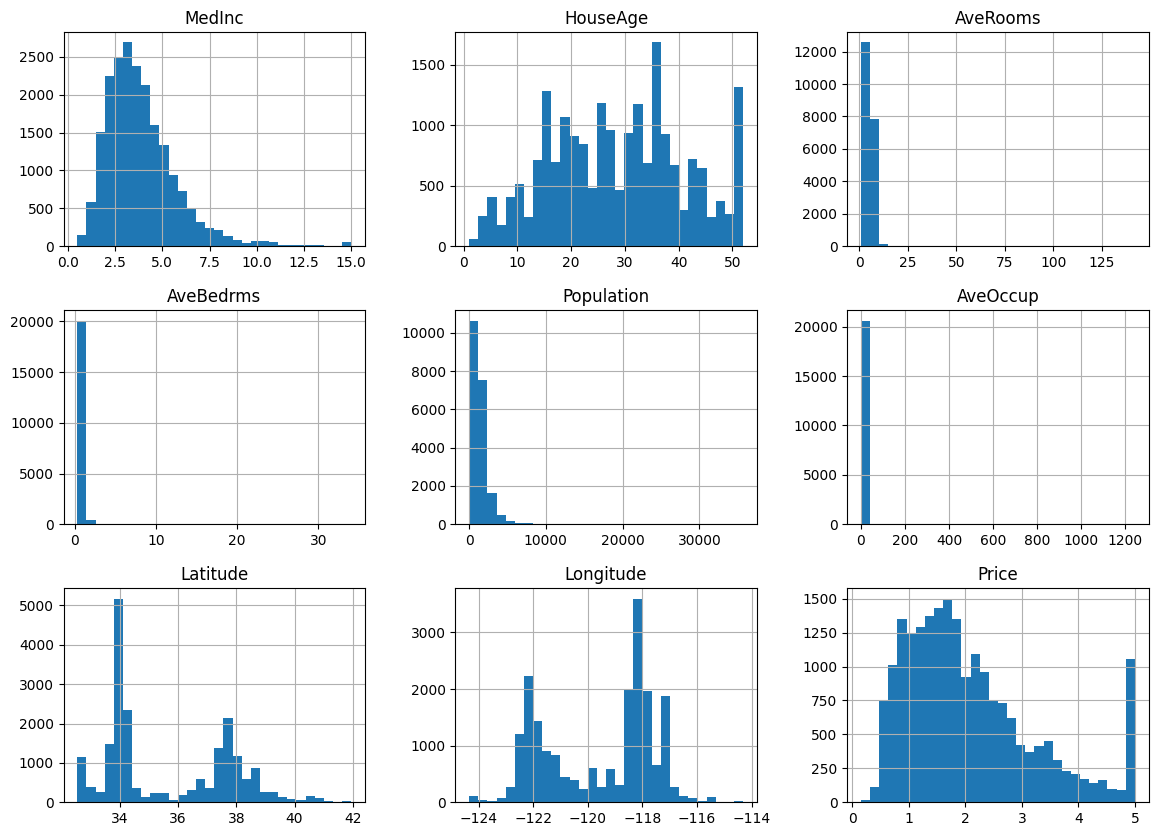

In [34]:
df.hist(
    figsize=(14,10),
    bins=30
)

plt.show()

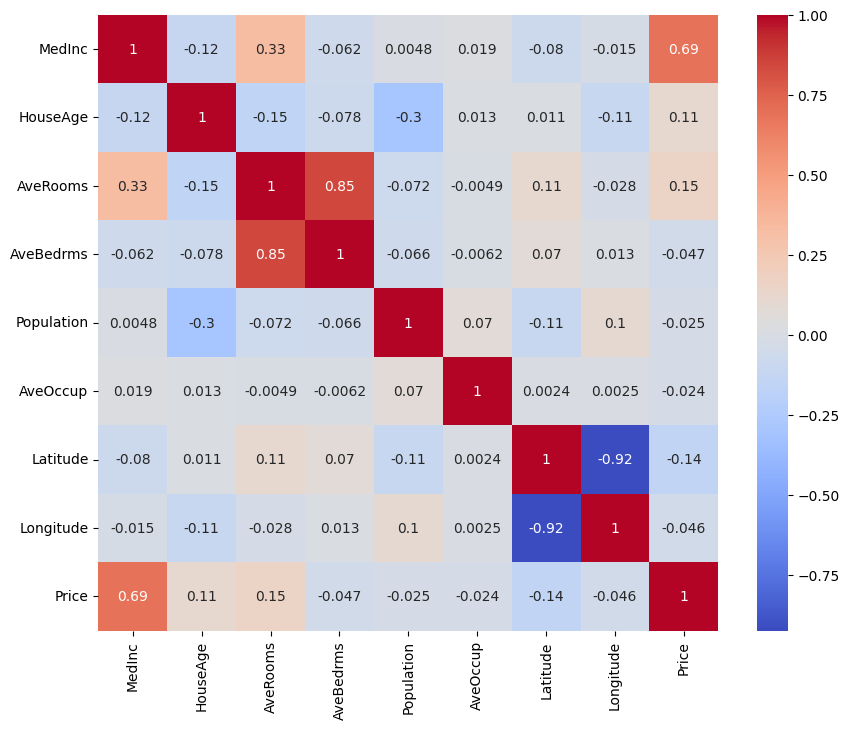

In [35]:
corr=df.corr()

corr["Price"].sort_values(
    ascending=False
)
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

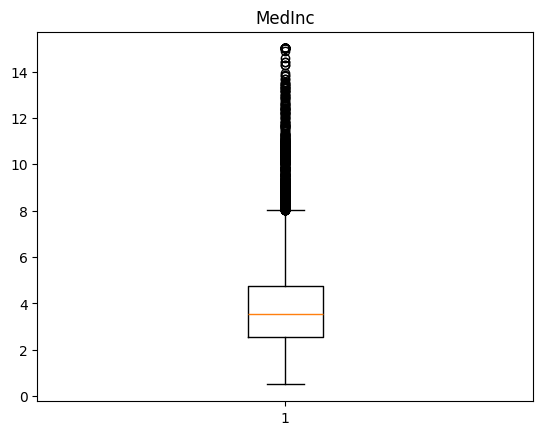

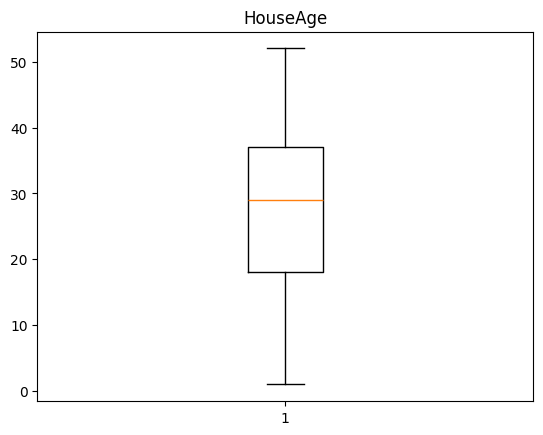

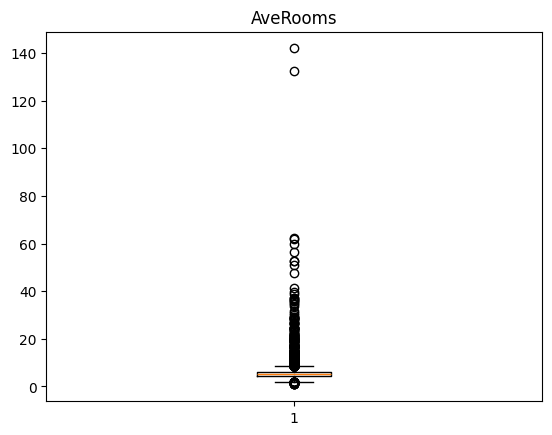

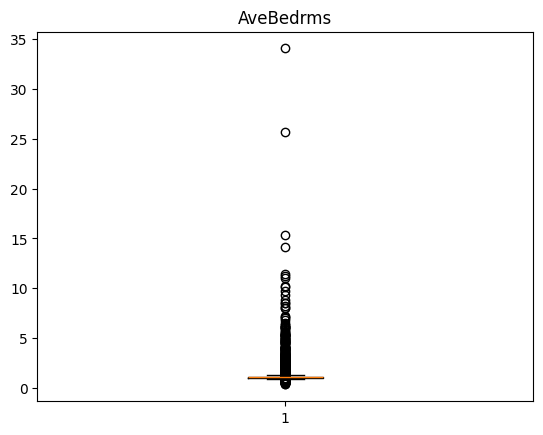

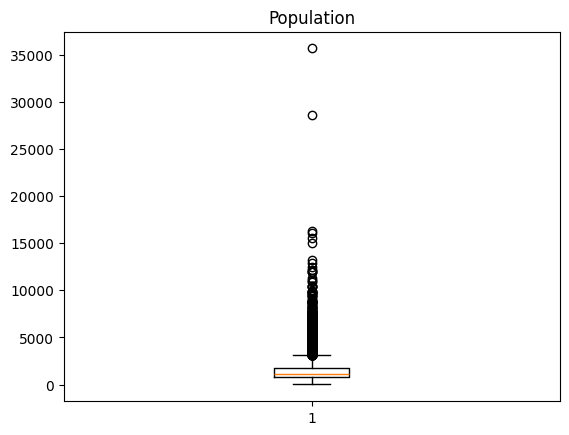

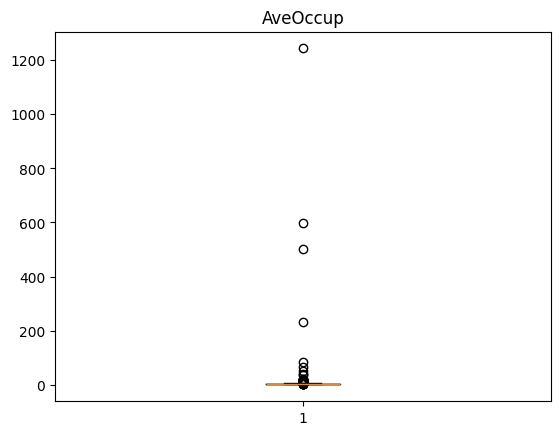

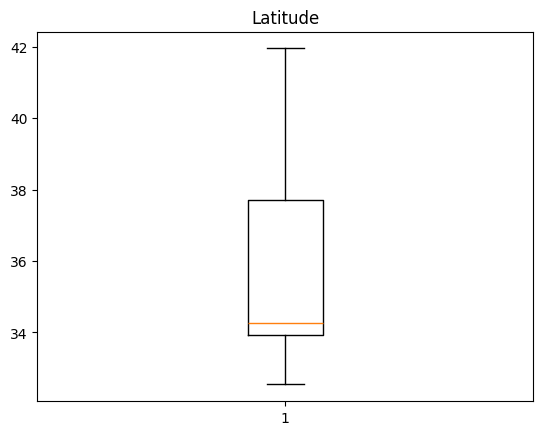

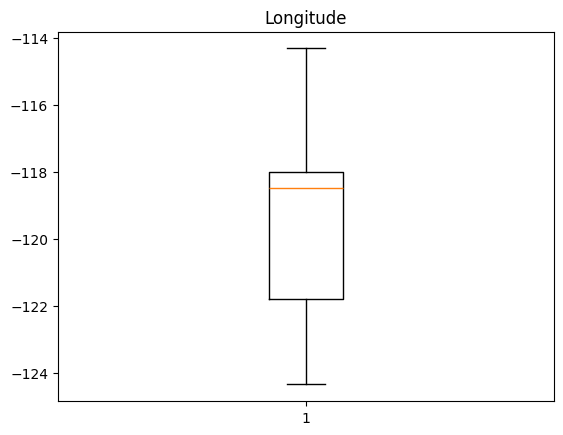

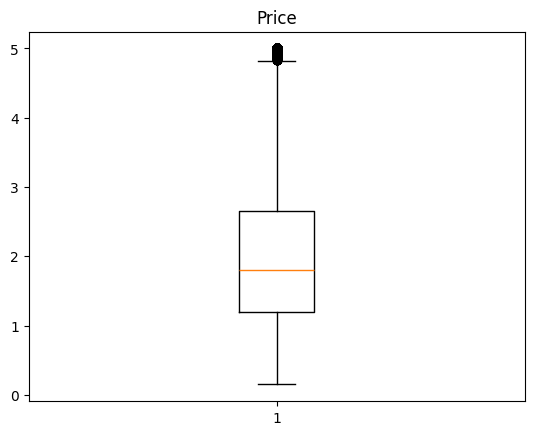

In [36]:
for col in df.columns:

    plt.figure()

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

In [37]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

X_scaled=pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42
)
X_train.shape
X_test.shape

(4128, 8)

In [39]:
X_train_simple = X_train[["MedInc"]]
X_test_simple = X_test[["MedInc"]]
print(X_train_simple.shape)
print(X_test_simple.shape)

(16512, 1)
(4128, 1)


## Ridge Regression (L2 Regularization) Formula

**The Ridge Regression Equation:**

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

**The Ridge Loss Function (with L2 Regularization):**

$$L(\beta) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

Where:
- **y** = dependent variable (target/price)
- **x₁, x₂, ..., xₙ** = independent variables (features)
- **β₀, β₁, ..., βₙ** = regression coefficients
- **λ (lambda/alpha)** = regularization parameter (controls penalty strength)
- **ε** = error term

**In Matrix Form:**
$$\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y$$

Where:
- **X** = design matrix
- **y** = target vector
- **I** = identity matrix
- **λ** = regularization parameter

**Key Concepts:**
- Ridge regression adds an L2 penalty term (λ∑βⱼ²) to the ordinary least squares loss
- This penalty shrinks the coefficients toward zero but doesn't set them exactly to zero
- Helps prevent overfitting by reducing model complexity
- The regularization parameter (α/λ) controls the strength of the penalty:
  - α = 0: Same as ordinary linear regression (no regularization)
  - α → ∞: Coefficients approach zero (strong regularization)
- Ridge is particularly useful when features are correlated (multicollinearity)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train,
    y_train
)

## Coefficient Interpretation

In Ridge regression, coefficients are shrunk toward zero compared to ordinary linear regression. This helps:
- Reduce model complexity
- Handle multicollinearity (correlated features)
- Improve generalization to new data

The degree of shrinkage depends on the alpha parameter.

In [ ]:
y_pred = ridge.predict(
    X_test
)

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse**0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R²:",r2)

In [ ]:
coef_df = pd.DataFrame({

    "Feature":X_train.columns,

    "Coefficient":ridge.coef_

})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

## Alpha Parameter Tuning

The regularization parameter (α) controls the trade-off between:
- **Bias**: Higher α increases bias (coefficients shrink more)
- **Variance**: Higher α reduces variance (less overfitting)

We test different α values to find the optimal balance:
- α = 0.01: Very weak regularization (similar to OLS)
- α = 0.1: Weak regularization
- α = 1.0: Moderate regularization (default)
- α = 10: Strong regularization
- α = 100: Very strong regularization

The best α is chosen based on cross-validation performance metrics.

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Ridge Regression"
)

plt.show()

In [ ]:
residuals = y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(y=0)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residual Plot"
)

plt.show()

In [ ]:
alphas=[0.01,0.1,1,10,100]

for a in alphas:

    model=Ridge(alpha=a)

    model.fit(
        X_train,
        y_train
    )

    pred=model.predict(
        X_test
    )

    r2=r2_score(
        y_test,
        pred
    )

    print(
        f"Alpha {a}: {r2}"
    )

In [ ]:
results.append({

    "Model":"Ridge Regression",

    "MAE":mae,

    "RMSE":rmse,

    "R2":r2
})

pd.DataFrame(results)